# Diversity Score

In [2]:
pip install "numpy>=1.25.0,<2.0"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 67.0 MB/s eta 0:00:0000:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.2
    Uninstalling numpy-2.1.2:
      Successfully uninstalled numpy-2.1.2
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy
print(numpy.__version__)


1.26.4


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datasets import load_dataset


model = SentenceTransformer('math-similarity/Bert-MLM_arXiv-MP-class_zbMath')


dataset = load_dataset('gsm8k', 'main')['train']


questions = [ex['question'] for ex in dataset]
embeddings = model.encode(questions, show_progress_bar=True)


diversity_matrix = 1 - cosine_similarity(embeddings)


def get_diversity_score(i, j):
    return diversity_matrix[i][j]


print(f"Diversity between sample 0 and 1: {get_diversity_score(0, 1):.4f}")
print(f"Diversity between sample 0 and itself: {get_diversity_score(0, 0):.4f}")


np.save('gsm8k_embeddings.npy', embeddings)
np.save('gsm8k_diversity_scores.npy', diversity_matrix)


/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Diversity between sample 0 and 1: 0.3810
Diversity between sample 0 and itself: -0.0000


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datasets import load_dataset


model = SentenceTransformer('all-mpnet-base-v2')


dataset = load_dataset('gsm8k', 'main')['train']


questions = [ex['question'] for ex in dataset]
embeddings = model.encode(questions, show_progress_bar=True)


diversity_matrix = 1 - cosine_similarity(embeddings)


def get_diversity_score(i, j):
    return diversity_matrix[i][j]


print(f"Diversity between sample 0 and 1: {get_diversity_score(0, 1):.4f}")
print(f"Diversity between sample 0 and itself: {get_diversity_score(0, 0):.4f}")


np.save('gsm8k_embeddings.npy', embeddings)
np.save('gsm8k_diversity_scores.npy', diversity_matrix)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Diversity between sample 0 and 1: 0.5020
Diversity between sample 0 and itself: 0.0000


In [5]:
pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


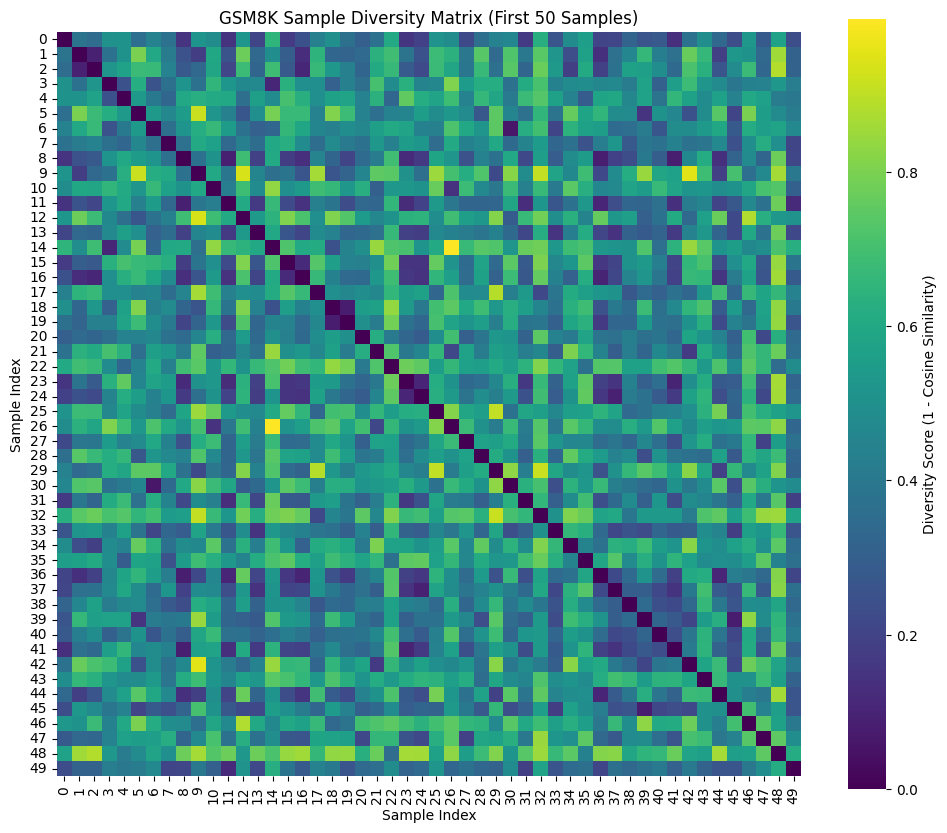

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

           cmap='viridis',
           square=True,
           cbar_kws={'label': 'Diversity Score (1 - Cosine Similarity)'})
plt.title('GSM8K Sample Diversity Matrix (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.show()

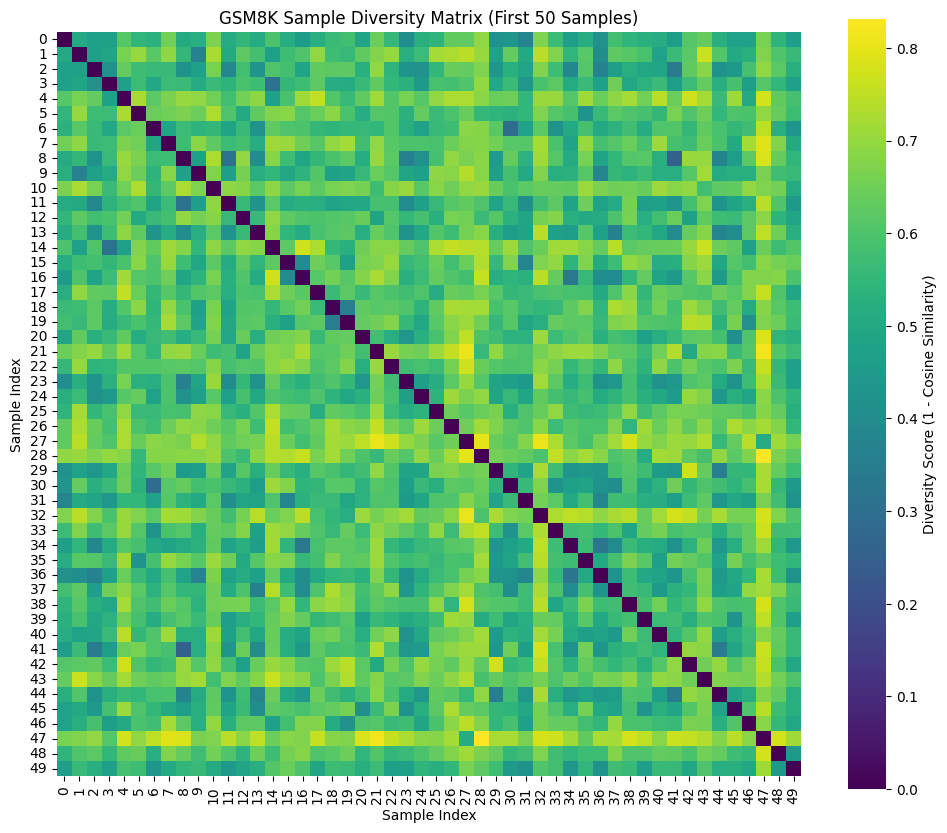

In [ ]:
# Now visualize
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

           cmap='viridis',
           square=True,
           cbar_kws={'label': 'Diversity Score (1 - Cosine Similarity)'})
plt.title('GSM8K Sample Diversity Matrix (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.show()